In [1]:
import numpy as np

import os

import xarray as xr

import pandas as pd

import pickle

import glob

import matplotlib.pyplot as plt

In [2]:
with open('/home/annierosen16/master_w_sp_2001_2025.pkl', 'rb') as f:
    
    master = pickle.load(f)
    
dryapes = master[master['dryape']==True]

wetapes = master[master['wetape']==True]

predryape = master[master['predryape']==True]

prewetape = master[master['prewetape']==True]

In [4]:
# base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

# years = [str(year) for year in range(2001, 2023)]

# def get_files(folder, component):
    
#     files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))
    
#     return [f for f in files if any(year in f for year in years)]

# # --- Load ERA5 files ---

# w_files = get_files('vertical_velocity', 'vertical_velocity')

# q_files = get_files('specific_humidity', 'specific_humidity')

# qw = xr.open_mfdataset(w_files + q_files, combine='by_coords', chunks={'time': 24})

In [3]:
# -----------------------------
# Settings
# -----------------------------

base_path = "/data/rong4/Data/ERA5/3hourly/quvw_US"

years = [str(year) for year in range(2001, 2023)]

LAT_N, LAT_S = 39, 30

LON_W, LON_E = -105, -95

WARM_MONTHS = [5, 6, 7, 8, 9]

w_2022_2025_path = "~/data/era5sgp/era5_ml_w_full_sgp_2022_2025"

q_2022_2025_path = "~/data/era5sgp/era5_ml_q_full_sgp_2022_2025"

# -----------------------------
# Helpers
# -----------------------------

def get_files(folder, component):
    
    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))
    
    return [f for f in files if any(year in f for year in years)]

def list_nc_files(path, contains=None):
    
    path = os.path.expanduser(path)
    
    files = sorted(glob.glob(os.path.join(path, "*.nc")))
    
    if contains is not None:
        
        files = [f for f in files if contains in os.path.basename(f)]
    
    return files

def rename_time_level(ds: xr.Dataset) -> xr.Dataset:
    
    rename_map = {}
    
    if "valid_time" in ds.dims or "valid_time" in ds.coords:
        
        rename_map["valid_time"] = "time"
    
    if "pressure_level" in ds.dims or "pressure_level" in ds.coords:
        
        rename_map["pressure_level"] = "level"
    
    return ds.rename(rename_map) if rename_map else ds

def harmonize_subset(ds: xr.Dataset, year_stop: int) -> xr.Dataset:
    
    """
    - subset domain
    - shift time to LST (UTC-6)
    - warm-season filter + year filter
    """
    
    ds = ds.sel(latitude=slice(LAT_N, LAT_S), longitude=slice(LON_W, LON_E))
    
    ds["time"] = ds["time"] - pd.Timedelta(hours=6)
    
    ds = ds.where(
        (ds.time.dt.month.isin(WARM_MONTHS)) &
        (ds.time.dt.year.isin(range(2001, year_stop + 1))),
        drop=True
    )
    return ds

def drop_duplicate_times(ds: xr.Dataset) -> xr.Dataset:
    
    t = pd.Index(ds.time.values)
    
    dupes = t.duplicated(keep="first")
    
    if dupes.any():
        
        ds = ds.isel(time=~xr.DataArray(dupes, dims="time"))
    
    return ds

# -----------------------------
# Load Yizhou (2001–2022)
# -----------------------------

w_files = get_files("vertical_velocity", "vertical_velocity")

q_files = get_files("specific_humidity", "specific_humidity")

qw_yz = xr.open_mfdataset(w_files + q_files, combine="by_coords", chunks={"time": 24})

qw_yz = harmonize_subset(qw_yz, year_stop=2022)

qw_yz = qw_yz.drop_vars("expver", errors="ignore")

# -----------------------------
# Load your 2022–2025 (q and w separately, then merge)
# -----------------------------

w_files_new = list_nc_files(w_2022_2025_path)

q_files_new = list_nc_files(q_2022_2025_path)

w_new = xr.open_mfdataset(w_files_new, combine="by_coords", chunks={"time": 24})

q_new = xr.open_mfdataset(q_files_new, combine="by_coords", chunks={"time": 24})

w_new = rename_time_level(w_new)

q_new = rename_time_level(q_new)

w_new = harmonize_subset(w_new, year_stop=2025)

q_new = harmonize_subset(q_new, year_stop=2025)

qw_new = xr.merge([q_new, w_new], compat="equals", join="exact")

qw_new = qw_new.drop_vars("expver", errors="ignore")

if "level" in qw_new.coords:
    
    qw_new = qw_new.sortby("level", ascending=True)

qw_new = qw_new.sortby("time")

# -----------------------------
# Keep only shared variables, concatenate, de-dupe, subset levels
# -----------------------------

common_vars = sorted(set(qw_yz.data_vars) & set(qw_new.data_vars))

qw_yz = qw_yz[common_vars]

qw_new = qw_new[common_vars]

qw = xr.concat([qw_yz, qw_new], dim="time", join="exact").sortby("time")

qw = drop_duplicate_times(qw)

# Optional: subset to just 800/600 hPa (only if those levels exist)
if "level" in qw.coords:
    
    wanted_levels = [lev for lev in [800, 600] if lev in set(qw["level"].values)]
    
    if wanted_levels:
        
        qw = qw.sel(level=wanted_levels)

print("qw ready:", qw)

qw ready: <xarray.Dataset> Size: 1GB
Dimensions:    (time: 30592, level: 2, latitude: 37, longitude: 41)
Coordinates:
  * longitude  (longitude) float32 164B -105.0 -104.8 -104.5 ... -95.25 -95.0
  * latitude   (latitude) float32 148B 39.0 38.75 38.5 38.25 ... 30.5 30.25 30.0
  * level      (level) int32 8B 800 600
  * time       (time) datetime64[ns] 245kB 2001-05-01 ... 2025-09-30T15:00:00
    number     int64 8B 0
Data variables:
    q          (time, level, latitude, longitude) float64 743MB dask.array<chunksize=(22, 2, 37, 41), meta=np.ndarray>
    w          (time, level, latitude, longitude) float64 743MB dask.array<chunksize=(22, 2, 37, 41), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2021-09-12 11:33:37 GMT by grib_to_netcdf-2.20.0: /opt/ecmw...


In [4]:
g = 9.81

qw["qw_mm_day"] = ( - (qw["q"] * qw["w"]) / g ) * 86400 # in ERA5, negative means upward motion, here i multiply by -1 to reverse that to make it easier to interpret

In [5]:
qw["qw800"] = qw["qw_mm_day"].sel(level=800)

qw["qw600"] = qw["qw_mm_day"].sel(level=600)

In [6]:
qw["qw_800_minus_600"] = (qw["qw_mm_day"].sel(level=800) - qw["qw_mm_day"].sel(level=600))

In [7]:
diff = qw["qw_800_minus_600"]   # dims: time, lat, lon (adjust names if needed)

diff_df = diff.to_dataframe(name="qw_800_minus_600").reset_index()

diff_df["day"] = diff_df["time"].dt.normalize()   # or .dt.floor("D")

diff_df = diff_df.sort_values("time")

# 5. Group by day + lat + lon and collect all intra-day values into arrays

diff_daily_grid_df = (diff_df.groupby(["day", "latitude", "longitude"])["qw_800_minus_600"]
      
                 .apply(lambda x: x.to_numpy())      # array over all times that day
      
                 .reset_index(name="qw_800_minus_600_array"))

In [8]:
_800qw = qw["qw800"]   # dims: time, lat, lon (adjust names if needed)

_800qw_df = _800qw.to_dataframe(name="qw800").reset_index()

_800qw_df["day"] = _800qw_df["time"].dt.normalize()   # or .dt.floor("D")

_800qw_df = _800qw_df.sort_values("time")

# 5. Group by day + lat + lon and collect all intra-day values into arrays

_800qw_daily_grid_df = (_800qw_df.groupby(["day", "latitude", "longitude"])["qw800"]
      
                 .apply(lambda x: x.to_numpy())      # array over all times that day
      
                 .reset_index(name="qw800"))

In [9]:
_600qw = qw["qw600"]   # dims: time, lat, lon (adjust names if needed)

_600qw_df = _600qw.to_dataframe(name="qw600").reset_index()

_600qw_df["day"] = _600qw_df["time"].dt.normalize()   # or .dt.floor("D")

_600qw_df = _600qw_df.sort_values("time")

# 5. Group by day + lat + lon and collect all intra-day values into arrays

_600qw_daily_grid_df = (_600qw_df.groupby(["day", "latitude", "longitude"])["qw600"]
      
                 .apply(lambda x: x.to_numpy())      # array over all times that day
      
                 .reset_index(name="qw600"))

In [10]:
diff_daily_grid_df = diff_daily_grid_df.rename(columns={"day": "date"})

diff_merged = master.merge(
    
    diff_daily_grid_df[["date", "latitude", "longitude", "qw_800_minus_600_array"]],
    
    on=["date", "latitude", "longitude"],
    
    how="left")

In [11]:
_800qw_daily_grid_df = _800qw_daily_grid_df.rename(columns={"day": "date"})

_800qw_merged = master.merge(
    
    _800qw_daily_grid_df[["date", "latitude", "longitude", "qw800"]],
    
    on=["date", "latitude", "longitude"],
    
    how="left")

In [12]:
_600qw_daily_grid_df = _600qw_daily_grid_df.rename(columns={"day": "date"})

_600qw_merged = master.merge(
    
    _600qw_daily_grid_df[["date", "latitude", "longitude", "qw600"]],
    
    on=["date", "latitude", "longitude"],
    
    how="left")

In [13]:
diff_dryapes = diff_merged[diff_merged["predryape"] == True]["qw_800_minus_600_array"] \
        .dropna() \
        .to_list()

diff_dry_arr = np.stack(diff_dryapes) # shape = (ndays_dry, nhours_per_day)

diff_dryapes_mean_diurnal_vertical_flux_diff = diff_dry_arr.mean(axis=0)

diff_wetapes = diff_merged[diff_merged["prewetape"] == True]["qw_800_minus_600_array"] \
        .dropna() \
        .to_list()

diff_wet_arr = np.stack(diff_wetapes) # shape = (ndays_dry, nhours_per_day)

diff_wetapes_mean_diurnal_vertical_flux_diff = diff_wet_arr.mean(axis=0)

In [14]:
_800qw_dryapes = _800qw_merged[_800qw_merged["predryape"] == True]["qw800"] \
        .dropna() \
        .to_list()

_800qw_dry_arr = np.stack(_800qw_dryapes) # shape = (ndays_dry, nhours_per_day)

_800qw_dryapes_mean_diurnal_vertical_flux_diff = _800qw_dry_arr.mean(axis=0)

_800qw_wetapes = _800qw_merged[_800qw_merged["prewetape"] == True]["qw800"] \
        .dropna() \
        .to_list()

_800qw_wet_arr = np.stack(_800qw_wetapes) # shape = (ndays_dry, nhours_per_day)

_800qw_wetapes_mean_diurnal_vertical_flux_diff = _800qw_wet_arr.mean(axis=0)

In [15]:
_600qw_dryapes = _600qw_merged[_600qw_merged["predryape"] == True]["qw600"] \
        .dropna() \
        .to_list()

_600qw_dry_arr = np.stack(_600qw_dryapes) # shape = (ndays_dry, nhours_per_day)

_600qw_dryapes_mean_diurnal_vertical_flux_diff = _600qw_dry_arr.mean(axis=0)

_600qw_wetapes = _600qw_merged[_600qw_merged["prewetape"] == True]["qw600"] \
        .dropna() \
        .to_list()

_600qw_wet_arr = np.stack(_600qw_wetapes) # shape = (ndays_dry, nhours_per_day)

_600qw_wetapes_mean_diurnal_vertical_flux_diff = _600qw_wet_arr.mean(axis=0)

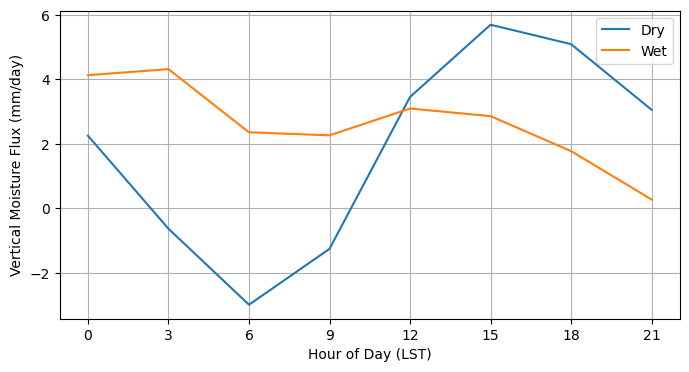

In [16]:
n = len(diff_dryapes_mean_diurnal_vertical_flux_diff)

hours = np.arange(n) * 3   # 0, 3, 6, 9, ...

plt.figure(figsize=(8,4))

plt.plot(hours, _800qw_dryapes_mean_diurnal_vertical_flux_diff, label='Dry')

plt.plot(hours, _800qw_wetapes_mean_diurnal_vertical_flux_diff, label='Wet')

plt.xlabel("Hour of Day (LST)")

plt.ylabel("Vertical Moisture Flux (mm/day)")

plt.xticks(hours)   # show every tick explicitly

plt.grid()

plt.legend()

plt.show()

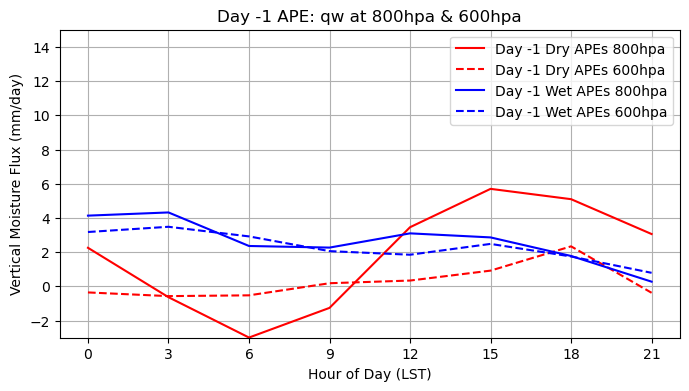

In [22]:
n = len(_800qw_dryapes_mean_diurnal_vertical_flux_diff)

hours = np.arange(n) * 3   # 0, 3, 6, 9, ...

plt.figure(figsize=(8,4))

plt.plot(hours, _800qw_dryapes_mean_diurnal_vertical_flux_diff, label='Day -1 Dry APEs 800hpa', color='red')

plt.plot(hours, _600qw_dryapes_mean_diurnal_vertical_flux_diff, label='Day -1 Dry APEs 600hpa', color='red', linestyle='--')

plt.plot(hours, _800qw_wetapes_mean_diurnal_vertical_flux_diff, label='Day -1 Wet APEs 800hpa', color='blue')

plt.plot(hours, _600qw_wetapes_mean_diurnal_vertical_flux_diff, label='Day -1 Wet APEs 600hpa', color='blue', linestyle='--')

plt.xlabel("Hour of Day (LST)")

plt.ylabel("Vertical Moisture Flux (mm/day)")

plt.xticks(hours)   # show every tick explicitly

plt.grid()

plt.ylim(-3, 15)

plt.title("Day -1 APE: qw at 800hpa & 600hpa")

plt.legend()

plt.show()

In [23]:
out_path = "/home/annierosen16/lt_diurnal_vertical_flux_diff_2001_2025_preapes.pkl"

data_to_save = {
    
    "dryapes_mean_diurnal_vertical_flux_diff": diff_dryapes_mean_diurnal_vertical_flux_diff,
    
    "wetapes_mean_diurnal_vertical_flux_diff": diff_wetapes_mean_diurnal_vertical_flux_diff,
}

with open(out_path, "wb") as f:
    
    pickle.dump(data_to_save, f)

print(f"Saved to {out_path}")

Saved to /home/annierosen16/lt_diurnal_vertical_flux_diff_2001_2025_preapes.pkl


In [24]:
out_path = "/home/annierosen16/_800qw_2001_2025_preapes.pkl"

data_to_save = {
    
    "_800qw_dryapes": _800qw_dryapes_mean_diurnal_vertical_flux_diff,
    
    "_800qw_wetapes": _800qw_wetapes_mean_diurnal_vertical_flux_diff,
}

with open(out_path, "wb") as f:
    
    pickle.dump(data_to_save, f)

print(f"Saved to {out_path}")

Saved to /home/annierosen16/_800qw_2001_2025_preapes.pkl


In [25]:
out_path = "/home/annierosen16/_600qw_2001_2025_preapes.pkl"

data_to_save = {
    
    "_600qw_dryapes": _600qw_dryapes_mean_diurnal_vertical_flux_diff,
    
    "_600qw_wetapes": _600qw_wetapes_mean_diurnal_vertical_flux_diff,
}

with open(out_path, "wb") as f:
    
    pickle.dump(data_to_save, f)

print(f"Saved to {out_path}")

Saved to /home/annierosen16/_600qw_2001_2025_preapes.pkl
